In [24]:
import pandas as pd
import seaborn as sns
import numpy as np
#(pip install imbalanced-learn)
from imblearn.over_sampling import SMOTE, ADASYN

df = pd.read_csv('../../Exercise_project_1\Classification_dataset\mushroom_reduced.csv')
df.head()

<>:7: SyntaxWarning: invalid escape sequence '\C'
<>:7: SyntaxWarning: invalid escape sequence '\C'
C:\Users\svetl\AppData\Local\Temp\ipykernel_18200\3839968545.py:7: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv('../../Exercise_project_1\Classification_dataset\mushroom_reduced.csv')


,class,does-bruise-or-bleed,stem-height,stem-width,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,...,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y
0,1,0,16.95,17.09,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,17.99,18.19,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,0,17.80,17.74,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,15.77,15.98,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,16.53,17.20,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [2]:
df = pd.read_csv('../../Exercise_project_1\Classification_dataset\mushroom_encoded.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\svetl\AppData\Local\Temp\ipykernel_18200\2219984729.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv('../../Exercise_project_1\Classification_dataset\mushroom_encoded.csv')


,class,cap-diameter,does-bruise-or-bleed,stem-height,stem-width,has-ring,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,...,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
0,1,15.26,0,16.95,17.09,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,16.60,0,17.99,18.19,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,14.07,0,17.80,17.74,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,14.17,0,15.77,15.98,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,1,14.64,0,16.53,17.20,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [13]:
# I will try to appy SMOTE on LabelEncoded categorical variaable - 'does-bruise-or-bleed' as only this variable from other Label Encoded variables important somehow for the target variable.
# I will treat 'class' as a feature variable here.

selected_variables = [
    'stem-width', 
    'stem-height',
    "class"
    ]
target = 'does-bruise-or-bleed'

# keep only the selected variables + target
df_label_en = df[selected_variables + [target]]


In [14]:
X = df_label_en.drop(target, axis=1)
y = df_label_en[target]

In [16]:
# huge imbalance. Binary variable - only two classes, so SMOTE can handle it well
print(y.value_counts().sort_index())

does-bruise-or-bleed
0    50479
1    10590
Name: count, dtype: int64


<Axes: xlabel='does-bruise-or-bleed'>

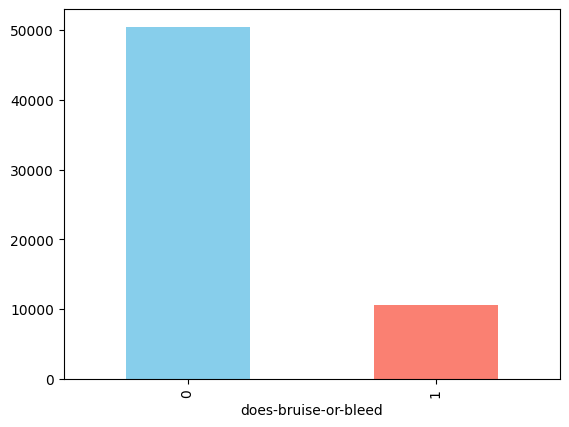

In [26]:
y.value_counts().sort_index().plot(kind='bar', color=['skyblue', 'salmon'])

In [19]:
# I will reduce imbalance (increase the minority class to 30000 samples):
strategy = {1: 30000} 

# use SMOTE with default settings (often enough)
# model = SMOTE()
model = SMOTE(sampling_strategy=strategy, random_state= 55)

# ADASYN is an alternative to SMOTE, but is often a bit trickier to
# use with custom sampling strategies, you can "auto" though
# model = ADASYN(sampling_strategy="auto", random_state=123)

X_resampled, y_resampled = model.fit_resample(X, y)

# reconstruct the dataframe
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled[target] = y_resampled

<Axes: xlabel='does-bruise-or-bleed', ylabel='Count'>

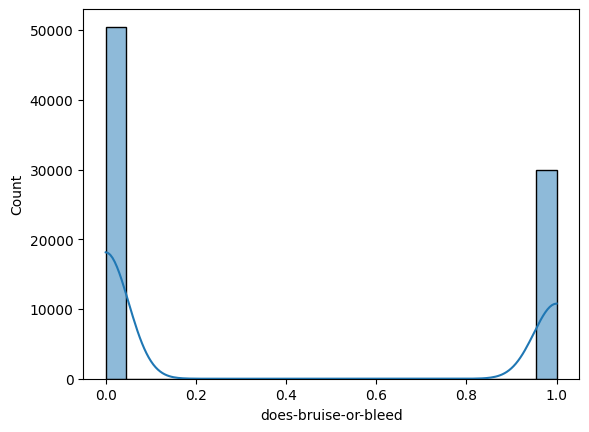

In [20]:
sns.histplot(data=df_resampled, x="does-bruise-or-bleed", kde=True)

In [21]:
df_label_en.describe()

,stem-width,stem-height,class,does-bruise-or-bleed
count,61069.000000,61069.000000,61069.000000,61069.000000
mean,12.149410,6.581538,0.554913,0.173410
std,10.035955,3.370017,0.496979,0.378605
min,0.000000,0.000000,0.000000,0.000000
25%,5.210000,4.640000,0.000000,0.000000
50%,10.190000,5.950000,1.000000,0.000000
75%,16.570000,7.740000,1.000000,0.000000
max,103.910000,33.920000,1.000000,1.000000


In [22]:
df_resampled.describe()

,stem-width,stem-height,class,does-bruise-or-bleed
count,80479.000000,80479.000000,80479.000000,80479.000000
mean,13.132113,6.716034,0.548652,0.372768
std,9.605784,3.130142,0.497630,0.483544
min,0.000000,0.000000,0.000000,0.000000
25%,6.090000,4.837305,0.000000,0.000000
50%,12.189550,6.150000,1.000000,0.000000
75%,17.590000,8.019586,1.000000,1.000000
max,103.910000,33.920000,1.000000,1.000000


In [23]:
df.corr()[target].sort_values(ascending=False)

does-bruise-or-bleed       1.000000
gill-attachment_d          0.325476
cap-shape_s                0.260575
gill-attachment_p          0.207827
stem-width                 0.183514
                             ...   
gill-attachment_f         -0.113449
gill-attachment_missing   -0.118368
season_w                  -0.121459
cap-shape_b               -0.146874
gill-attachment_a         -0.197054
Name: does-bruise-or-bleed, Length: 95, dtype: float64